<a href="https://colab.research.google.com/github/CianaHoggard/ClassificationOfDiabetes/blob/main/ClassificationOfDiabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Valid Zeros:
Pregnancies: 14.5% zeros are valid (represents women who have never been pregnant)
Outcome: 65.1% zeros are valid (represents negative diabetes cases)

Problematic Zeros:
Insulin: 48.7% zeros (very high, likely missing data)
SkinThickness: 29.6% zeros (very high, likely missing data)
BloodPressure: 4.6% zeros (medically impossible)
Glucose: 0.7% zeros (medically impossible)
BMI: 1.4% zeros (medically impossible)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

diabetes = pd.read_csv("/content/drive/MyDrive/Diabetes/diabetes.csv")


feature_info = {
    'Glucose': {
        'min_valid': 45,
        'max_valid': 600,
        'context': """
        - Severe hypoglycemia: < 45 mg/dL (life-threatening)
        - Normal fasting: 70-99 mg/dL
        - Prediabetes: 100-125 mg/dL
        - Diabetes: ≥ 126 mg/dL
        - Severe hyperglycemia: > 200 mg/dL
        - Diabetic crisis: > 600 mg/dL (DKA/HHS)
        """
    },
    'BloodPressure': {
        'min_valid': 40,
        'max_valid': 300,
        'context': """
        - Severe hypotension: < 40 mmHg (shock)
        - Normal: 90/60 - 120/80 mmHg
        - Hypertension: > 140/90 mmHg
        - Hypertensive crisis: > 180/120 mmHg
        - Emergency maximum: ~300 mmHg systolic
        """
    },
    'SkinThickness': {
        'min_valid': 10,
        'max_valid': 150,
        'context': """
        - Minimum healthy: ~10 mm
        - Normal range: 20-40 mm
        - Varies by:
          * Body composition
          * Measurement site
          * Gender and age
        - Extreme obesity: up to 150 mm
        """
    },
    'Insulin': {
        'min_valid': 0,
        'max_valid': 1000,
        'context': """
        - Fasting: < 25 μU/mL
        - 2 hours post-glucose: < 130 μU/mL
        - Insulin resistance: Can exceed 300 μU/mL
        - Extreme cases: Up to 1000 μU/mL
        - Zero possible in fasting state
        """
    },
    'BMI': {
        'min_valid': 13,
        'max_valid': 100,
        'context': """
        - Severe underweight: < 16 kg/m²
        - Normal weight: 18.5-24.9 kg/m²
        - Overweight: 25-29.9 kg/m²
        - Obese: ≥ 30 kg/m²
        - Extreme obesity: > 40 kg/m²
        - Maximum recorded: ~100 kg/m²
        """
    }
}


DATASET OVERVIEW

Dataset Shape: (768, 9)

Feature Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Summary Statistics:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.

<Figure size 1500x1000 with 0 Axes>

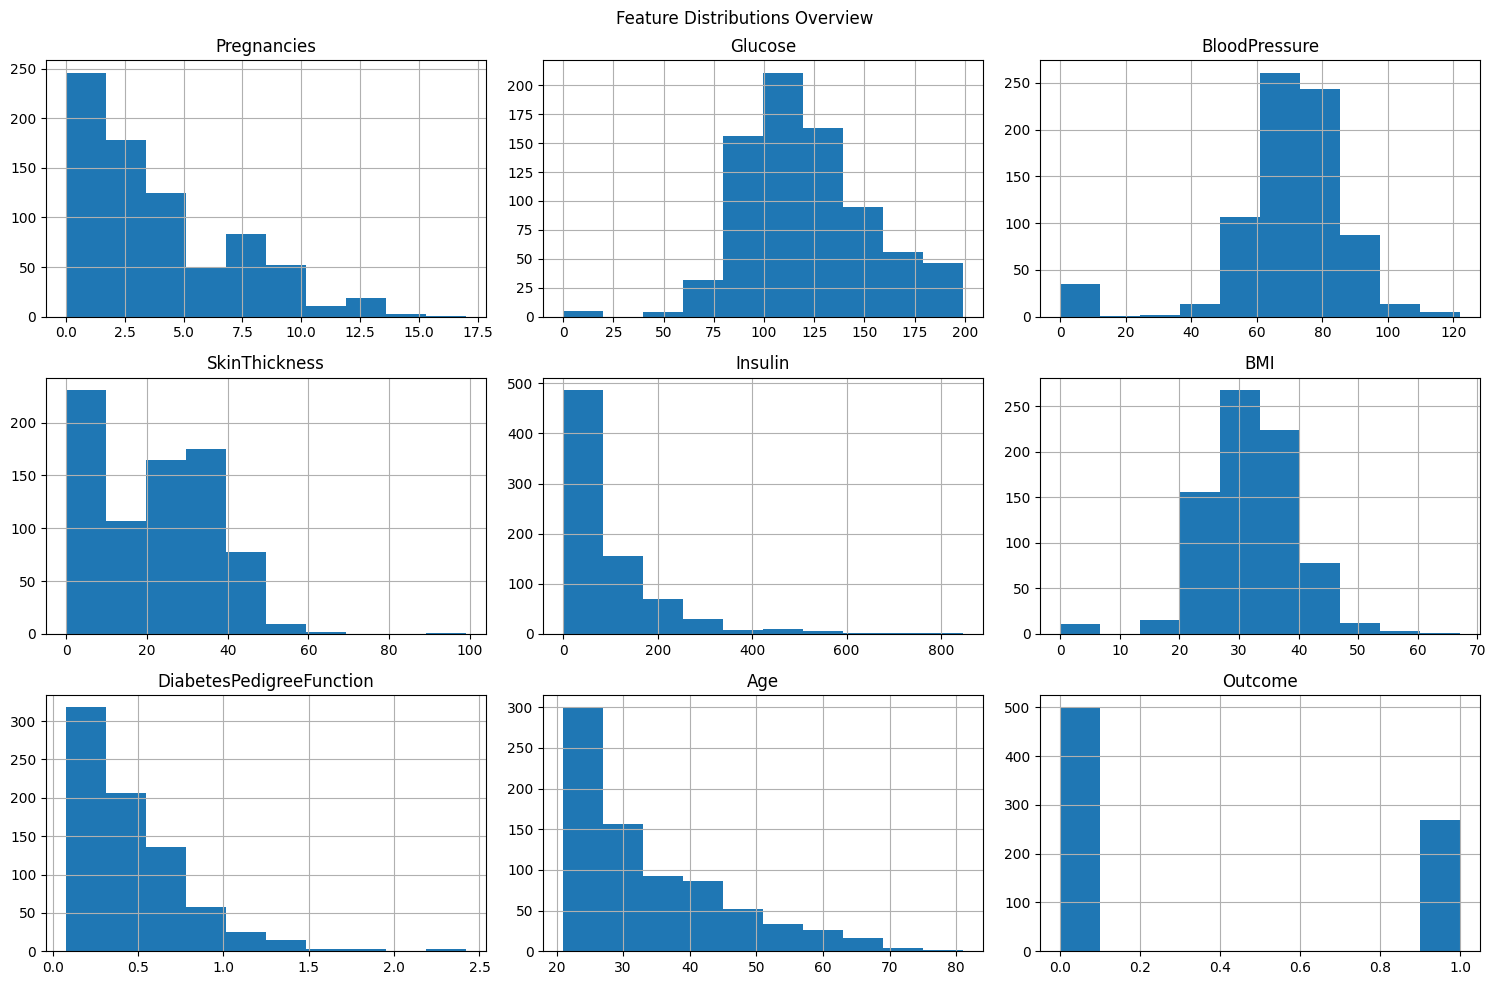


CORRELATION ANALYSIS


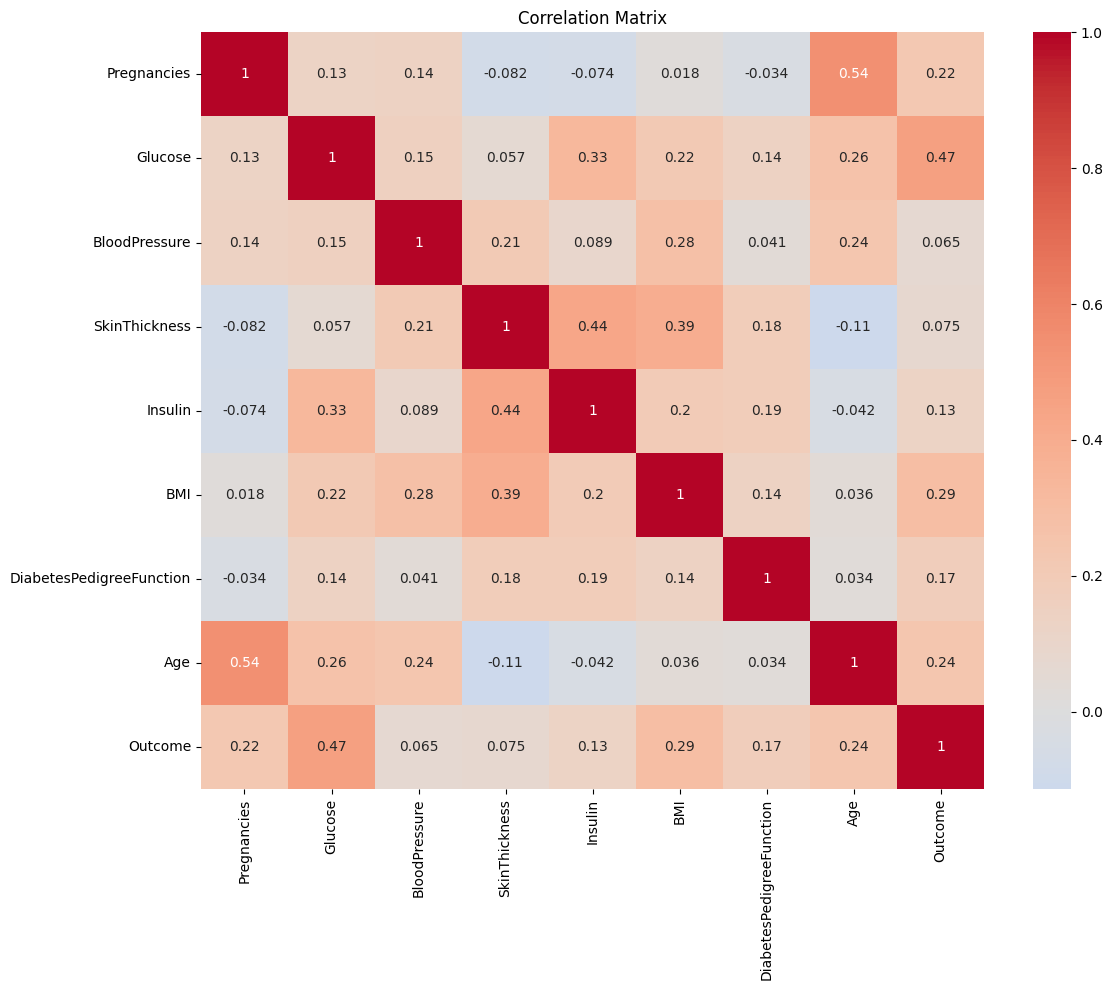


Strong Correlations (|r| > 0.3):
Insulin vs Glucose: 0.331
Insulin vs SkinThickness: 0.437
BMI vs SkinThickness: 0.393
Age vs Pregnancies: 0.544
Outcome vs Glucose: 0.467

OUTCOME ANALYSIS

Outcome Distribution:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


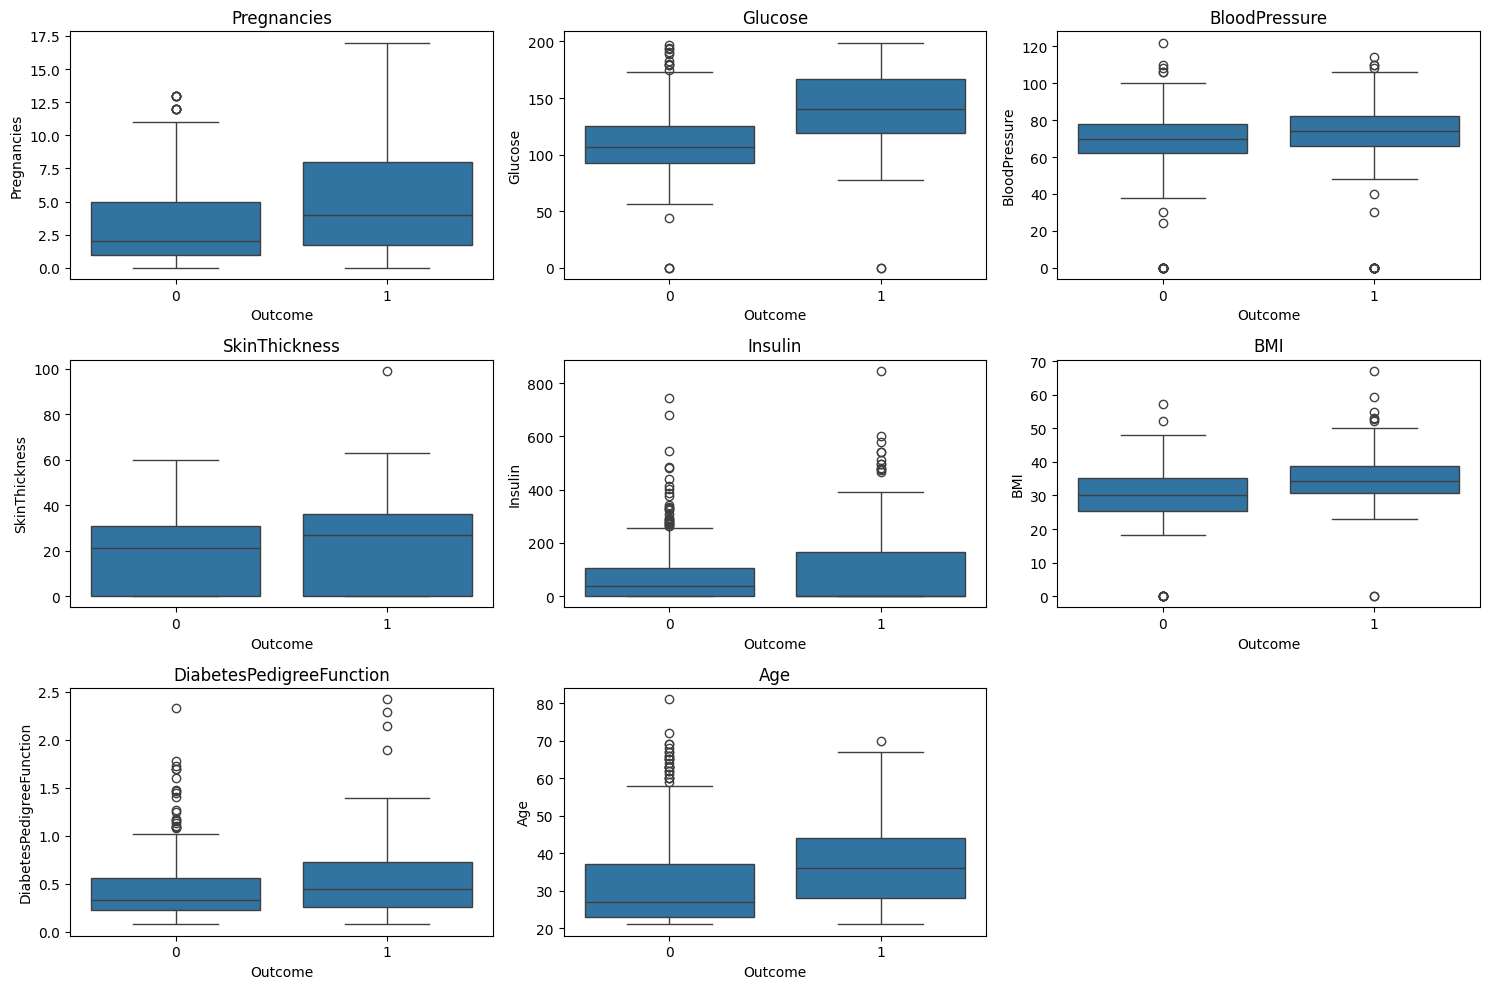


DETAILED FEATURE ANALYSIS

Analyzing Glucose


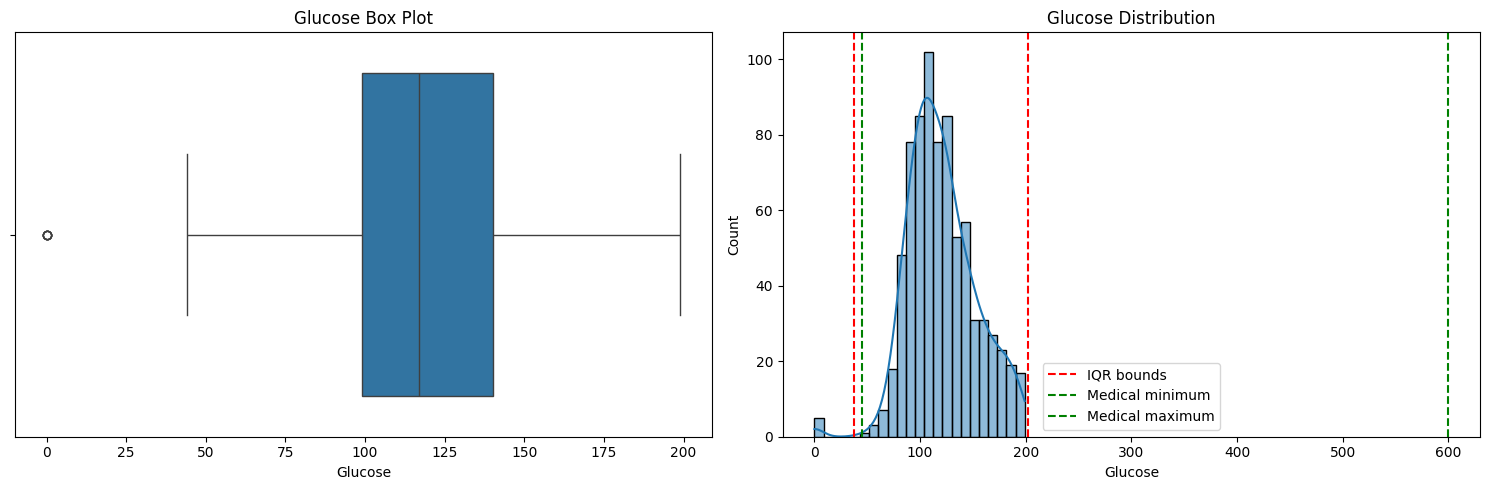


Analysis for Glucose:
Mean: 120.89
Median: 117.00
Standard deviation: 31.97

IQR bounds: 37.12 to 202.12
Values below IQR bound: 5
Values above IQR bound: 0

Z-score outliers (>3 SD): 5

Z-score outlier values:
[0 0 0 0 0]

Medical Range Analysis:
Values below minimum (45): 6
Values above maximum (600): 0

Distribution of values below medical minimum:
Glucose
0     5
44    1
Name: count, dtype: int64

Medical Context for Glucose:

        - Severe hypoglycemia: < 45 mg/dL (life-threatening)
        - Normal fasting: 70-99 mg/dL
        - Prediabetes: 100-125 mg/dL
        - Diabetes: ≥ 126 mg/dL
        - Severe hyperglycemia: > 200 mg/dL
        - Diabetic crisis: > 600 mg/dL (DKA/HHS)
        

Quality Metrics:
Zero values: 5 (0.7%)


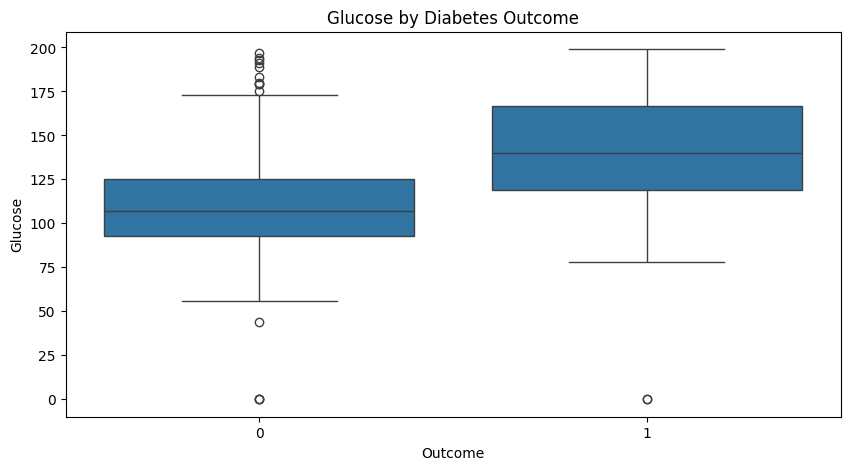


Analyzing BloodPressure


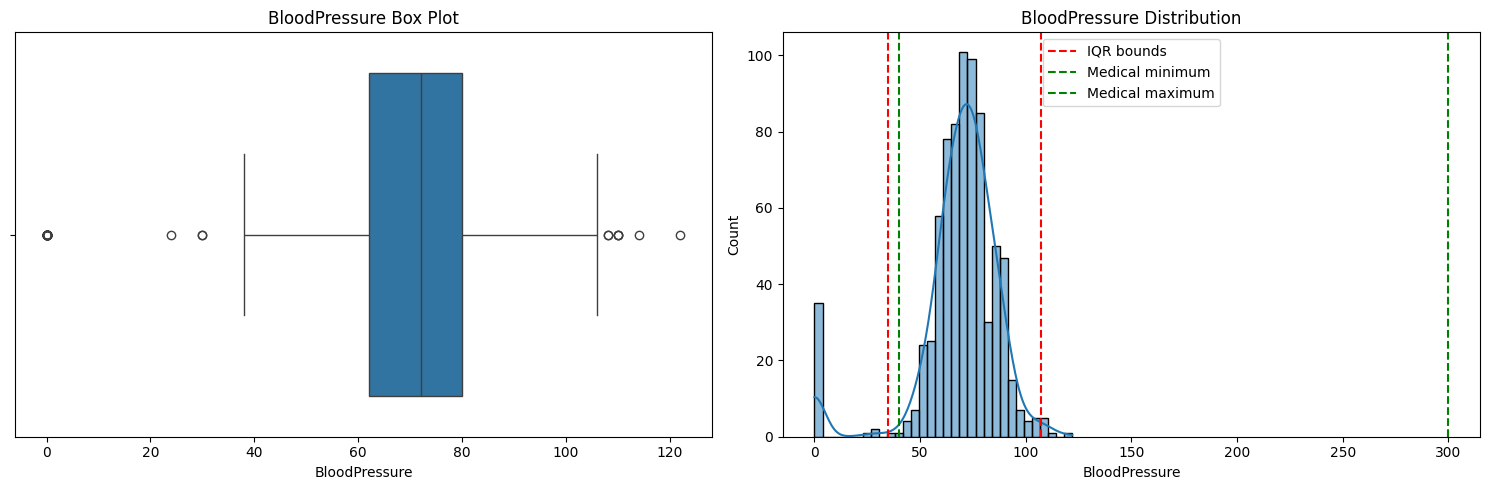


Analysis for BloodPressure:
Mean: 69.11
Median: 72.00
Standard deviation: 19.36

IQR bounds: 35.00 to 107.00
Values below IQR bound: 38
Values above IQR bound: 7

Z-score outliers (>3 SD): 35

Z-score outlier values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Medical Range Analysis:
Values below minimum (40): 39
Values above maximum (300): 0

Distribution of values below medical minimum:
BloodPressure
0     35
24     1
30     2
38     1
Name: count, dtype: int64

Medical Context for BloodPressure:

        - Severe hypotension: < 40 mmHg (shock)
        - Normal: 90/60 - 120/80 mmHg
        - Hypertension: > 140/90 mmHg
        - Hypertensive crisis: > 180/120 mmHg
        - Emergency maximum: ~300 mmHg systolic
        

Quality Metrics:
Zero values: 35 (4.6%)


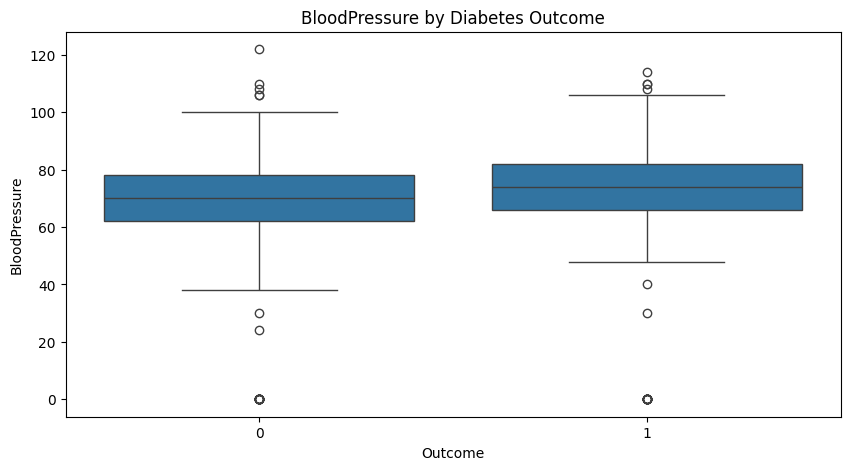


Analyzing SkinThickness


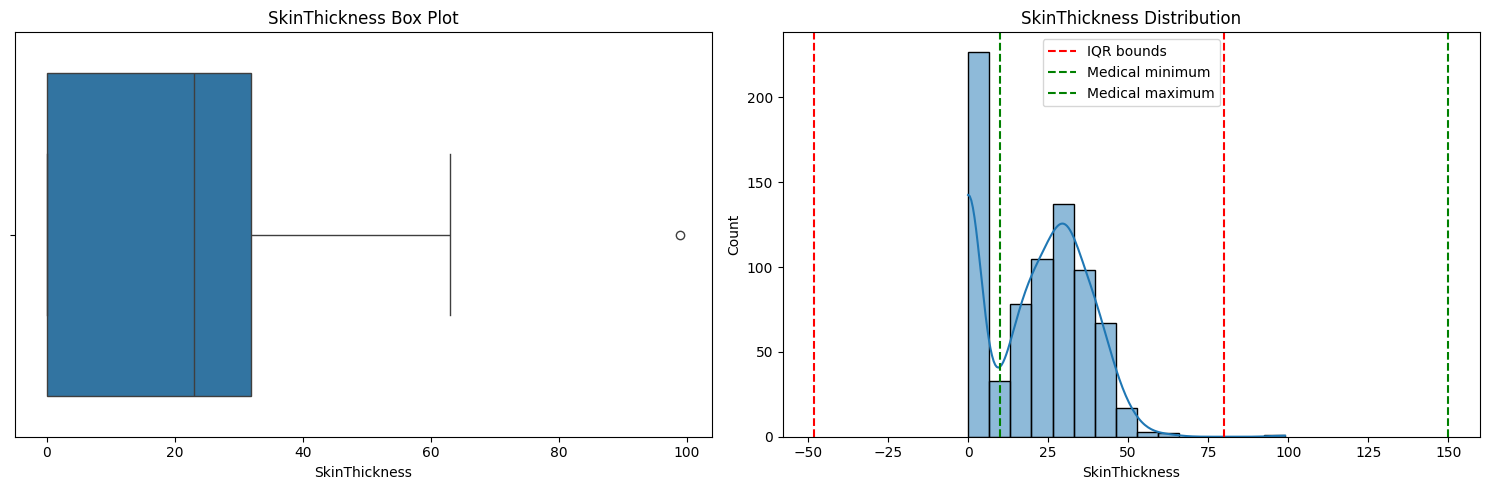


Analysis for SkinThickness:
Mean: 20.54
Median: 23.00
Standard deviation: 15.95

IQR bounds: -48.00 to 80.00
Values below IQR bound: 0
Values above IQR bound: 1

Z-score outliers (>3 SD): 1

Z-score outlier values:
[99]

Medical Range Analysis:
Values below minimum (10): 231
Values above maximum (150): 0

Distribution of values below medical minimum:
SkinThickness
0    227
7      2
8      2
Name: count, dtype: int64

Medical Context for SkinThickness:

        - Minimum healthy: ~10 mm
        - Normal range: 20-40 mm
        - Varies by:
          * Body composition
          * Measurement site
          * Gender and age
        - Extreme obesity: up to 150 mm
        

Quality Metrics:
Zero values: 227 (29.6%)


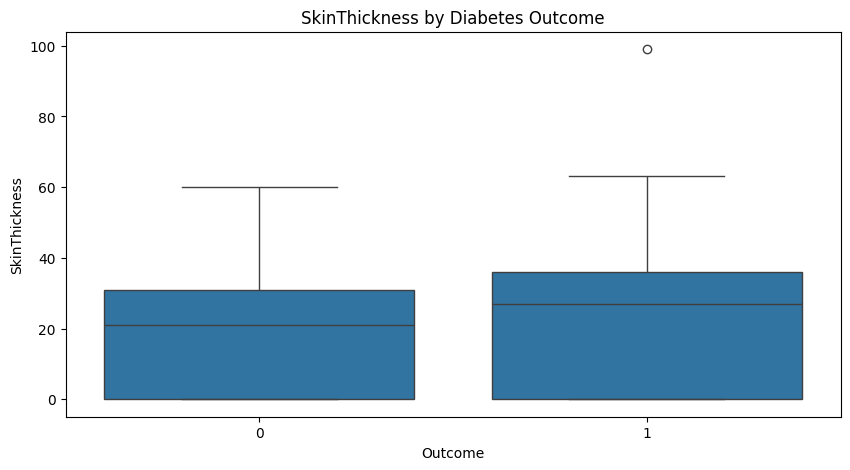


Analyzing Insulin


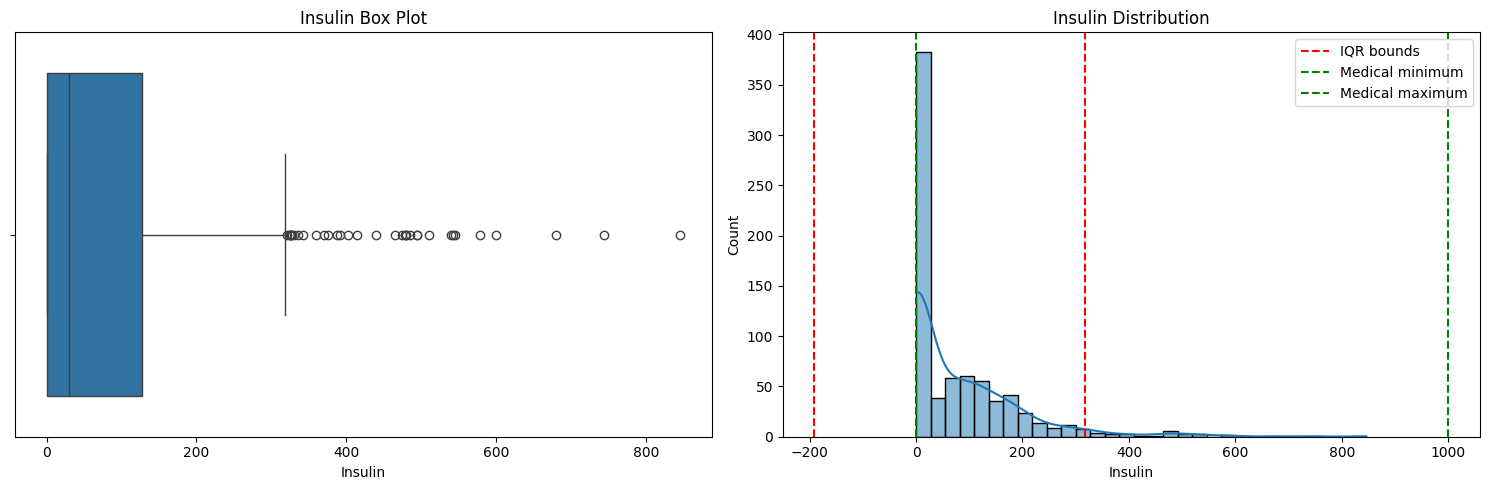


Analysis for Insulin:
Mean: 79.80
Median: 30.50
Standard deviation: 115.24

IQR bounds: -190.88 to 318.12
Values below IQR bound: 0
Values above IQR bound: 34

Z-score outliers (>3 SD): 18

Z-score outlier values:
[440 465 474 478 480 480 485 495 495 510 540 543 545 579 600 680 744 846]

Medical Range Analysis:
Values below minimum (0): 0
Values above maximum (1000): 0

Medical Context for Insulin:

        - Fasting: < 25 μU/mL
        - 2 hours post-glucose: < 130 μU/mL
        - Insulin resistance: Can exceed 300 μU/mL
        - Extreme cases: Up to 1000 μU/mL
        - Zero possible in fasting state
        

Quality Metrics:
Zero values: 374 (48.7%)


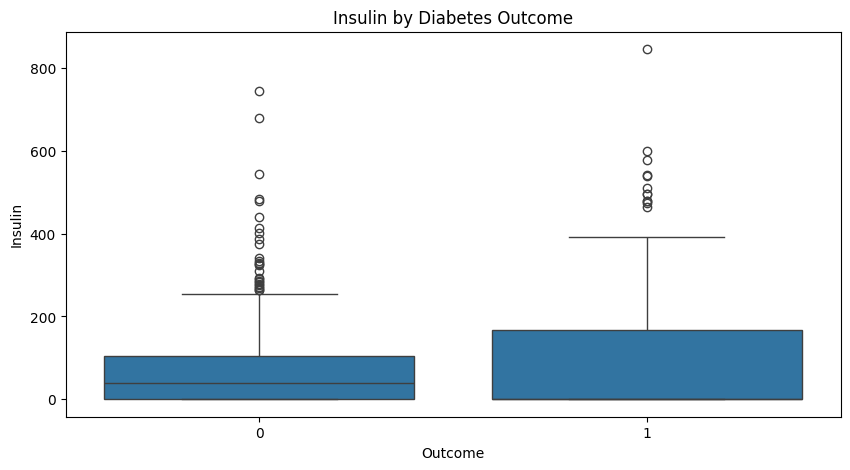


Analyzing BMI


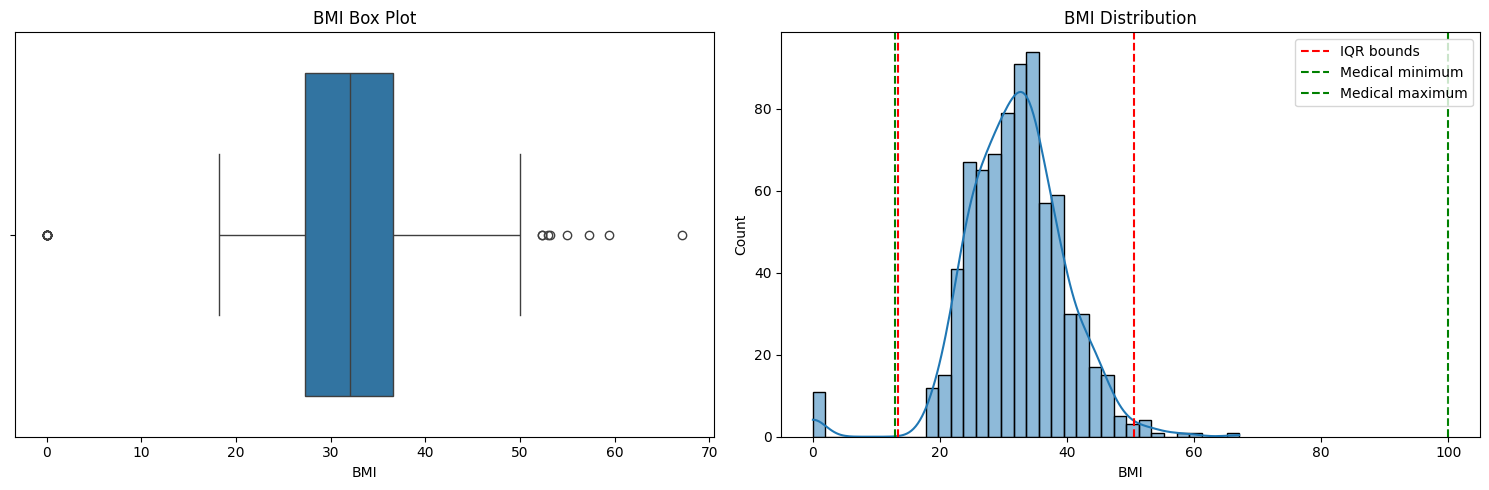


Analysis for BMI:
Mean: 31.99
Median: 32.00
Standard deviation: 7.88

IQR bounds: 13.35 to 50.55
Values below IQR bound: 11
Values above IQR bound: 8

Z-score outliers (>3 SD): 14

Z-score outlier values:
[ 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  57.3 59.4 67.1]

Medical Range Analysis:
Values below minimum (13): 11
Values above maximum (100): 0

Distribution of values below medical minimum:
BMI
0.0    11
Name: count, dtype: int64

Medical Context for BMI:

        - Severe underweight: < 16 kg/m²
        - Normal weight: 18.5-24.9 kg/m²
        - Overweight: 25-29.9 kg/m²
        - Obese: ≥ 30 kg/m²
        - Extreme obesity: > 40 kg/m²
        - Maximum recorded: ~100 kg/m²
        

Quality Metrics:
Zero values: 11 (1.4%)


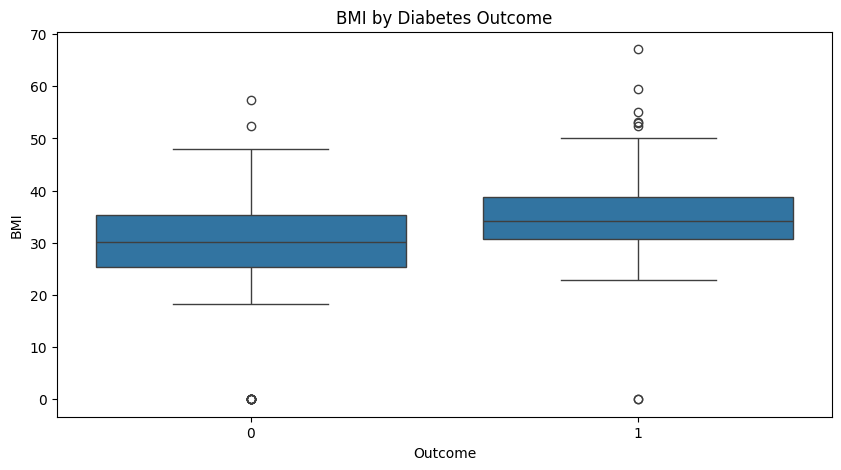

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


def analyze_feature_distribution(df, feature, medical_info):

    data = df[feature]

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    z_scores = np.abs(stats.zscore(data))
    z_score_outliers = data[z_scores > 3]

    plt.figure(figsize=(15, 5))

    plt.subplot(121)
    sns.boxplot(x=data)
    plt.title(f'{feature} Box Plot')

    plt.subplot(122)
    sns.histplot(data=data, kde=True)
    plt.axvline(lower_bound, color='r', linestyle='--', label='IQR bounds')
    plt.axvline(upper_bound, color='r', linestyle='--')
    if 'min_valid' in medical_info:
        plt.axvline(medical_info['min_valid'], color='g', linestyle='--',
                   label='Medical minimum')
    if 'max_valid' in medical_info:
        plt.axvline(medical_info['max_valid'], color='g', linestyle='--',
                   label='Medical maximum')
    plt.title(f'{feature} Distribution')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"\nAnalysis for {feature}:")
    print(f"Mean: {data.mean():.2f}")
    print(f"Median: {data.median():.2f}")
    print(f"Standard deviation: {data.std():.2f}")
    print(f"\nIQR bounds: {lower_bound:.2f} to {upper_bound:.2f}")
    print(f"Values below IQR bound: {len(data[data < lower_bound])}")
    print(f"Values above IQR bound: {len(data[data > upper_bound])}")
    print(f"\nZ-score outliers (>3 SD): {len(z_score_outliers)}")

    if len(z_score_outliers) > 0:
        print("\nZ-score outlier values:")
        print(z_score_outliers.sort_values().values)

    if 'min_valid' in medical_info:
        below_min = len(data[data < medical_info['min_valid']])
        above_max = len(data[data > medical_info['max_valid']])
        print(f"\nMedical Range Analysis:")
        print(f"Values below minimum ({medical_info['min_valid']}): {below_min}")
        print(f"Values above maximum ({medical_info['max_valid']}): {above_max}")
        if below_min > 0:
            print("\nDistribution of values below medical minimum:")
            print(data[data < medical_info['min_valid']].value_counts().sort_index())
        if above_max > 0:
            print("\nDistribution of values above medical maximum:")
            print(data[data > medical_info['max_valid']].value_counts().sort_index())

def analyze_diabetes_data(df):
    """
    Comprehensive EDA for diabetes dataset
    """
    print("="*50)
    print("DATASET OVERVIEW")
    print("="*50)
    print("\nDataset Shape:", df.shape)
    print("\nFeature Information:")
    print(df.info())
    print("\nSummary Statistics:")
    print(df.describe().round(2))

    print("\n" + "="*50)
    print("ZERO VALUES ANALYSIS")
    print("="*50)
    zero_analysis = pd.DataFrame({
        'Zero Count': (df == 0).sum(),
        'Zero Percentage': ((df == 0).sum() / len(df) * 100).round(2)
    })
    print(zero_analysis)

    print("\n" + "="*50)
    print("OVERALL DISTRIBUTIONS")
    print("="*50)

    plt.figure(figsize=(15, 10))
    df.hist(figsize=(15, 10))
    plt.suptitle('Feature Distributions Overview')
    plt.tight_layout()
    plt.show()

    print("\n" + "="*50)
    print("CORRELATION ANALYSIS")
    print("="*50)

    plt.figure(figsize=(12, 10))
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

    print("\nStrong Correlations (|r| > 0.3):")
    for i in range(len(correlation_matrix.columns)):
        for j in range(i):
            if abs(correlation_matrix.iloc[i, j]) > 0.3:
                print(f"{correlation_matrix.columns[i]} vs {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

    print("\n" + "="*50)
    print("OUTCOME ANALYSIS")
    print("="*50)

    print("\nOutcome Distribution:")
    outcome_dist = df['Outcome'].value_counts(normalize=True) * 100
    print(outcome_dist.round(2))


    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(df.columns[:-1]):
        plt.subplot(3, 3, i+1)
        sns.boxplot(x='Outcome', y=feature, data=df)
        plt.title(feature)
    plt.tight_layout()
    plt.show()


    print("\n" + "="*50)
    print("DETAILED FEATURE ANALYSIS")
    print("="*50)

    for feature, info in feature_info.items():
        print(f"\n{'='*50}")
        print(f"Analyzing {feature}")
        print('='*50)

        analyze_feature_distribution(df, feature, info)
        print(f"\nMedical Context for {feature}:")
        print(info['context'])


        zeros = (df[feature] == 0).sum()
        print(f"\nQuality Metrics:")
        print(f"Zero values: {zeros} ({(zeros/len(df)*100):.1f}%)")


        plt.figure(figsize=(10, 5))
        sns.boxplot(x='Outcome', y=feature, data=df)
        plt.title(f'{feature} by Diabetes Outcome')
        plt.show()


analyze_diabetes_data(diabetes)


Processing Glucose (mg/dL):

Original statistics:
count    768.00
mean     120.89
std       31.97
min        0.00
25%       99.00
50%      117.00
75%      140.25
max      199.00
Name: Glucose, dtype: float64
Number of zeros: 5

Replacing 6 invalid values
Distribution of invalid values:
Glucose
0     5
44    1
Name: count, dtype: int64
Replacement value (median of valid values): 117.00

Processed statistics:
count    768.00
mean     121.75
std       30.31
min       56.00
25%      100.00
50%      117.00
75%      140.25
max      199.00
Name: Glucose, dtype: float64


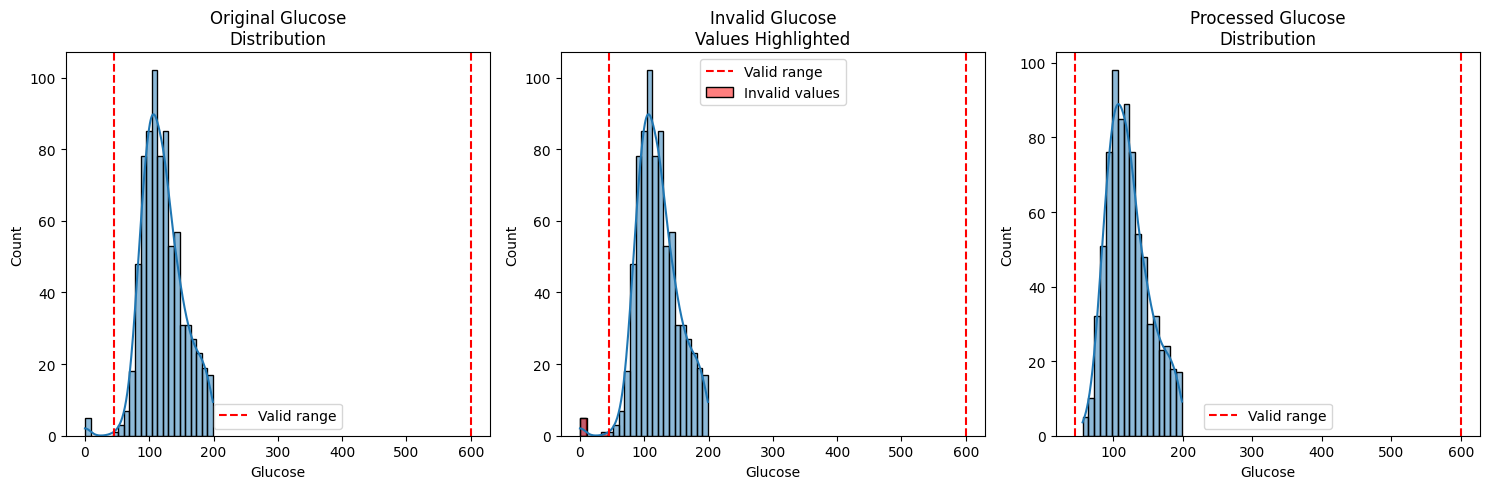


Processing BloodPressure (mmHg):

Original statistics:
count    768.00
mean      69.11
std       19.36
min        0.00
25%       62.00
50%       72.00
75%       80.00
max      122.00
Name: BloodPressure, dtype: float64
Number of zeros: 35

Replacing 39 invalid values
Distribution of invalid values:
BloodPressure
0     35
24     1
30     2
38     1
Name: count, dtype: int64
Replacement value (median of valid values): 72.00

Processed statistics:
count    768.0
mean      72.6
std       11.7
min       40.0
25%       64.0
50%       72.0
75%       80.0
max      122.0
Name: BloodPressure, dtype: float64


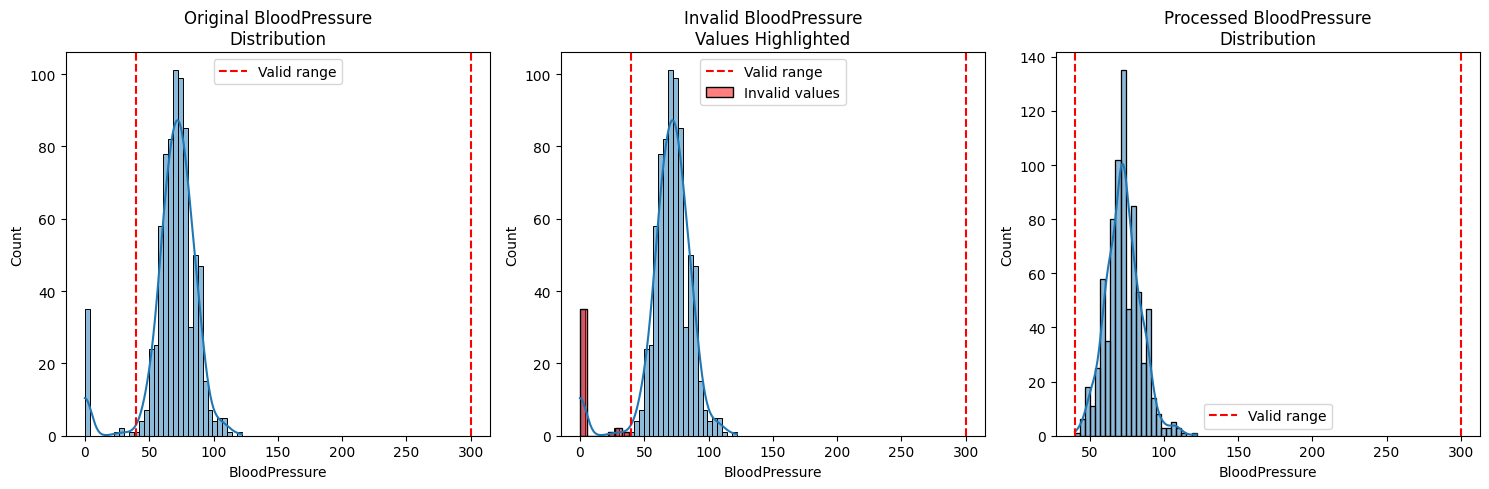


Processing SkinThickness (mm):

Original statistics:
count    768.00
mean      20.54
std       15.95
min        0.00
25%        0.00
50%       23.00
75%       32.00
max       99.00
Name: SkinThickness, dtype: float64
Number of zeros: 227

Replacing 231 invalid values
Distribution of invalid values:
SkinThickness
0    227
7      2
8      2
Name: count, dtype: int64
Replacement value (median of valid values): 29.00

Processed statistics:
count    768.00
mean      29.22
std        8.65
min       10.00
25%       25.00
50%       29.00
75%       32.00
max       99.00
Name: SkinThickness, dtype: float64


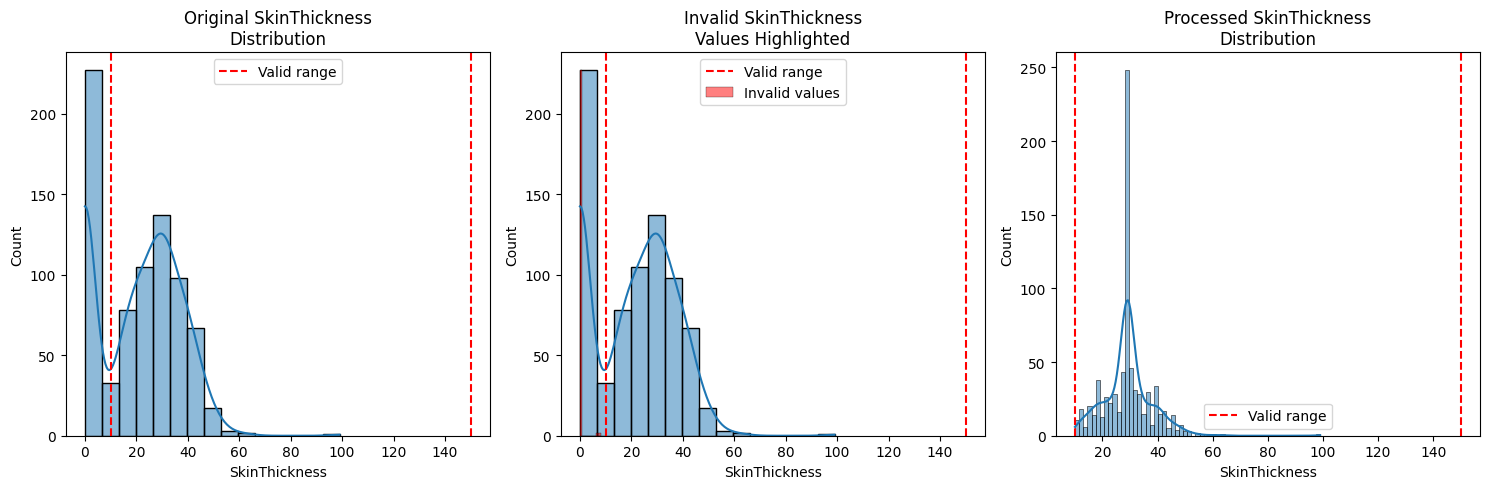


Processing Insulin (μU/mL):

Original statistics:
count    768.00
mean      79.80
std      115.24
min        0.00
25%        0.00
50%       30.50
75%      127.25
max      846.00
Name: Insulin, dtype: float64
Number of zeros: 374

Processed statistics:
count    768.00
mean      79.80
std      115.24
min        0.00
25%        0.00
50%       30.50
75%      127.25
max      846.00
Name: Insulin, dtype: float64


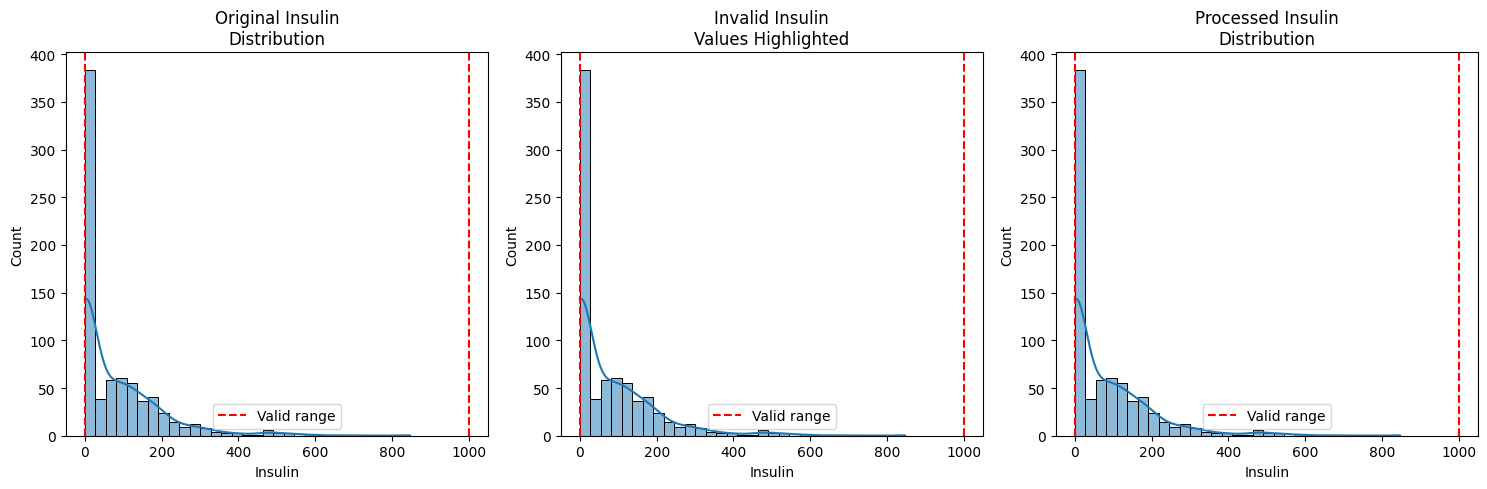


Processing BMI (kg/m²):

Original statistics:
count    768.00
mean      31.99
std        7.88
min        0.00
25%       27.30
50%       32.00
75%       36.60
max       67.10
Name: BMI, dtype: float64
Number of zeros: 11

Replacing 11 invalid values
Distribution of invalid values:
BMI
0.0    11
Name: count, dtype: int64
Replacement value (median of valid values): 32.30

Processed statistics:
count    768.00
mean      32.46
std        6.88
min       18.20
25%       27.50
50%       32.30
75%       36.60
max       67.10
Name: BMI, dtype: float64


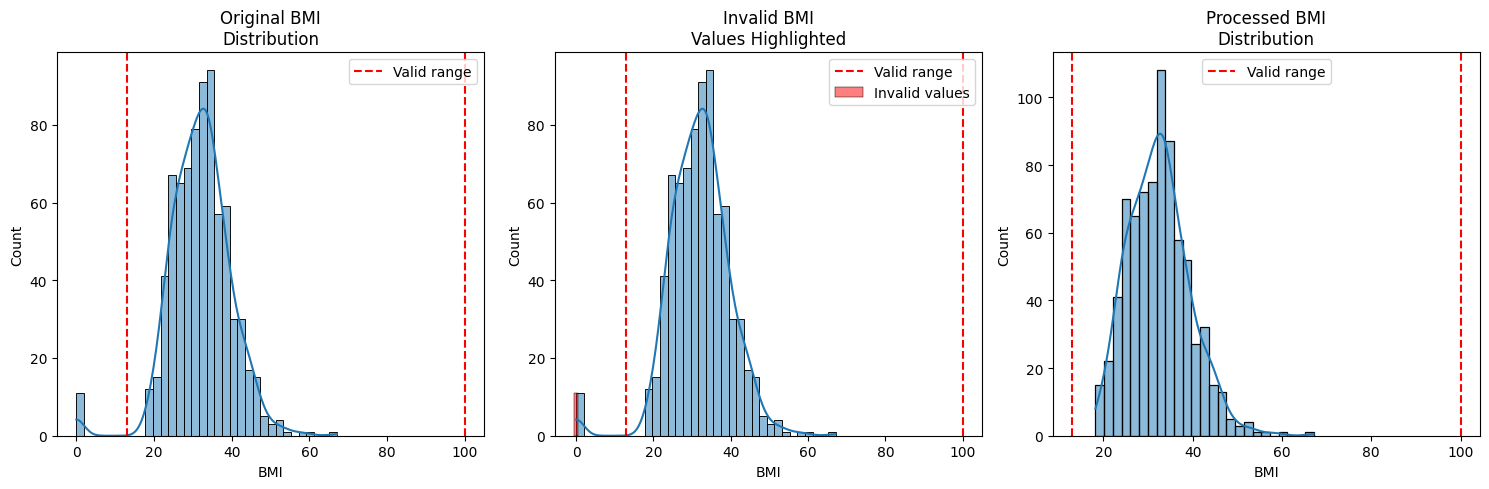

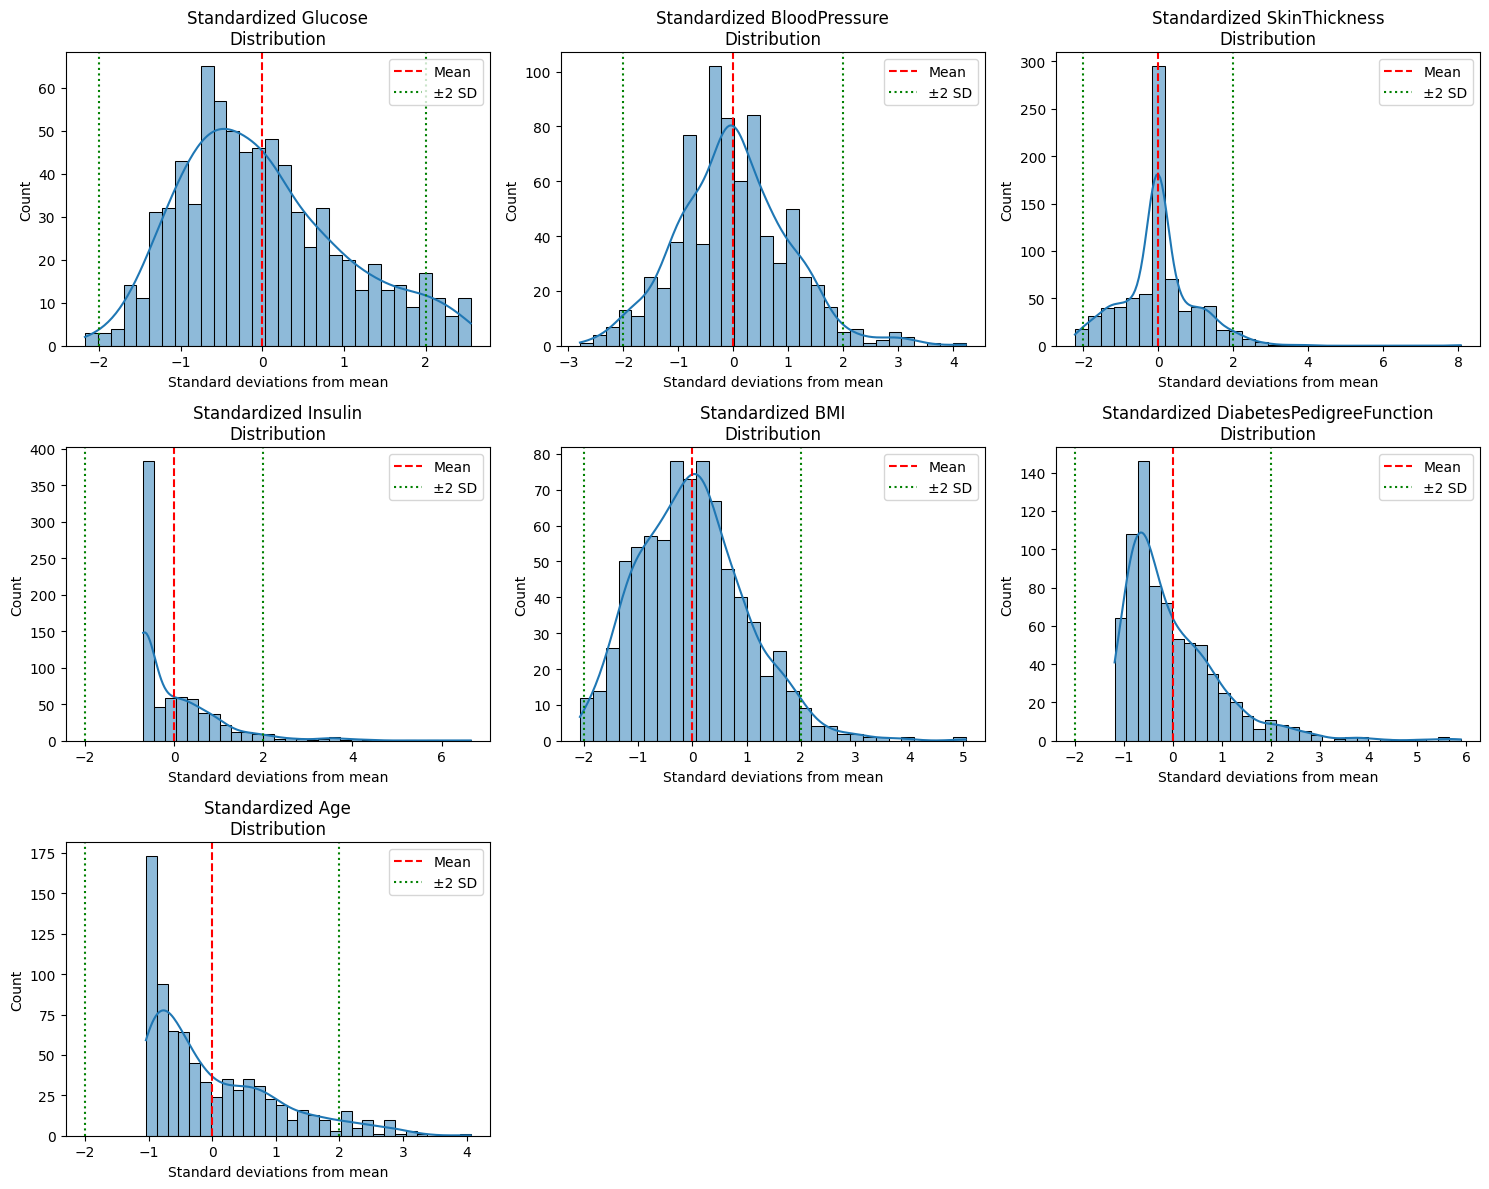


Final processed data summary:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85     0.00           0.00           0.00    -0.00    0.00   
std           3.37     1.00           1.00           1.00     1.00    1.00   
min           0.00    -2.17          -2.79          -2.22    -0.69   -2.07   
25%           1.00    -0.72          -0.74          -0.49    -0.69   -0.72   
50%           3.00    -0.16          -0.05          -0.03    -0.43   -0.02   
75%           6.00     0.61           0.63           0.32     0.41    0.60   
max          17.00     2.55           4.22           8.07     6.65    5.04   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.00    0.00     0.35  
std                        1.00    1.00     0.48  
min                       -1.19   -1.04     0.00  
25%        

In [10]:
def preprocess_diabetes_data_updated(df):
    df_processed = df.copy()


    updated_thresholds = {
        'Glucose': {
            'min': 45,
            'max': 600,
            'unit': 'mg/dL'
        },
        'BloodPressure': {
            'min': 40,
            'max': 300,
            'unit': 'mmHg'
        },
        'SkinThickness': {
            'min': 10,
            'max': 150,
            'unit': 'mm'
        },
        'Insulin': {
            'min': 0,
            'max': 1000,
            'unit': 'μU/mL'
        },
        'BMI': {
            'min': 13,
            'max': 100,
            'unit': 'kg/m²'
        }
    }


    for feature, thresholds in updated_thresholds.items():
        print(f"\n{'='*50}")
        print(f"Processing {feature} ({thresholds['unit']}):")


        print("\nOriginal statistics:")
        print(df_processed[feature].describe().round(2))
        print(f"Number of zeros: {(df_processed[feature] == 0).sum()}")


        valid_mask = (df_processed[feature] >= thresholds['min']) & \
                    (df_processed[feature] <= thresholds['max'])
        valid_values = df_processed[valid_mask][feature]


        replacement_value = valid_values.median()


        invalid_mask = ~valid_mask
        if invalid_mask.sum() > 0:
            print(f"\nReplacing {invalid_mask.sum()} invalid values")
            print("Distribution of invalid values:")
            print(df_processed[invalid_mask][feature].value_counts().sort_index())
            print(f"Replacement value (median of valid values): {replacement_value:.2f}")

            df_processed.loc[invalid_mask, feature] = replacement_value


        print("\nProcessed statistics:")
        print(df_processed[feature].describe().round(2))


        plt.figure(figsize=(15, 5))


        plt.subplot(131)
        sns.histplot(data=df[feature], kde=True)
        plt.axvline(thresholds['min'], color='r', linestyle='--', label='Valid range')
        plt.axvline(thresholds['max'], color='r', linestyle='--')
        plt.title(f'Original {feature}\nDistribution')
        plt.legend()


        plt.subplot(132)
        sns.histplot(data=df[feature], kde=True)
        invalid_data = df[invalid_mask][feature]
        if len(invalid_data) > 0:
            sns.histplot(data=invalid_data, color='red', alpha=0.5, label='Invalid values')
        plt.axvline(thresholds['min'], color='r', linestyle='--', label='Valid range')
        plt.axvline(thresholds['max'], color='r', linestyle='--')
        plt.title(f'Invalid {feature}\nValues Highlighted')
        plt.legend()


        plt.subplot(133)
        sns.histplot(data=df_processed[feature], kde=True)
        plt.axvline(thresholds['min'], color='r', linestyle='--', label='Valid range')
        plt.axvline(thresholds['max'], color='r', linestyle='--')
        plt.title(f'Processed {feature}\nDistribution')
        plt.legend()

        plt.tight_layout()
        plt.show()


    features_to_scale = list(updated_thresholds.keys()) + ['DiabetesPedigreeFunction', 'Age']
    scaler = StandardScaler()
    df_processed[features_to_scale] = scaler.fit_transform(df_processed[features_to_scale])


    n_features = len(features_to_scale)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    plt.figure(figsize=(15, 12))

    for idx, feature in enumerate(features_to_scale, 1):
        plt.subplot(3, 3, idx)
        sns.histplot(data=df_processed[feature], kde=True, bins=30)


        plt.axvline(0, color='red', linestyle='--', label='Mean')
        plt.axvline(-2, color='green', linestyle=':', label='±2 SD')
        plt.axvline(2, color='green', linestyle=':')

        plt.title(f'Standardized {feature}\nDistribution')
        plt.xlabel('Standard deviations from mean')
        plt.ylabel('Count')
        plt.legend()

    plt.tight_layout()
    plt.savefig('standardized_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nFinal processed data summary:")
    print(df_processed.describe().round(2))

    return df_processed, scaler


diabetes_processed_updated, scaler_updated = preprocess_diabetes_data_updated(diabetes)

In [11]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns


X = diabetes_processed_updated.drop('Outcome', axis=1)
y = diabetes_processed_updated['Outcome']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (614, 8)
Testing set shape: (154, 8)


Logistic Regression

In [12]:
print("\n=== Logistic Regression Experiment ===")
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)


log_pred = log_reg.predict(X_test)
log_prob = log_reg.predict_proba(X_test)[:, 1]


fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
roc_auc_log = auc(fpr_log, tpr_log)
print("\nLogistic Regression Results:")
print(classification_report(y_test, log_pred))


plt.figure(figsize=(15, 5))



=== Logistic Regression Experiment ===

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Random Forest

In [13]:
print("\n=== Random Forest Experiment ===")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)


rf_pred = rf_clf.predict(X_test)
rf_prob = rf_clf.predict_proba(X_test)[:, 1]


fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

print("\nRandom Forest Results:")
print(classification_report(y_test, rf_pred))


plt.figure(figsize=(15, 5))



=== Random Forest Experiment ===

Random Forest Results:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        99
           1       0.67      0.67      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

SVM

In [14]:
print("\n=== Step 5: SVM Experiment ===")
svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train, y_train)

svm_pred = svm_clf.predict(X_test)
svm_prob = svm_clf.predict_proba(X_test)[:, 1]


fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)
roc_auc_svm = auc(fpr_svm, tpr_svm)


print("\nSVM Results:")
print(classification_report(y_test, svm_pred))


plt.figure(figsize=(15, 5))


=== Step 5: SVM Experiment ===

SVM Results:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83        99
           1       0.71      0.58      0.64        55

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>


=== Model Comparison ===


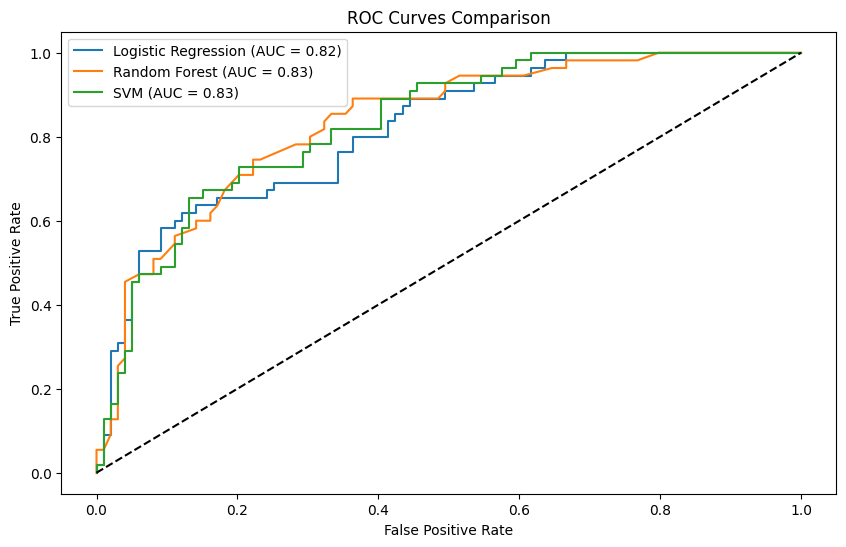

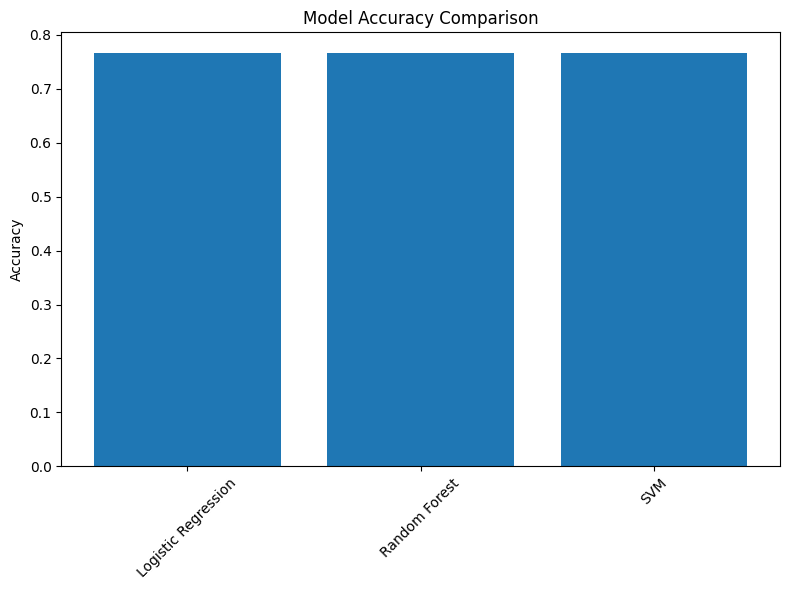


Final Model Performance Summary:
Logistic Regression Accuracy: 0.766
Random Forest Accuracy: 0.766
SVM Accuracy: 0.766


In [15]:
print("\n=== Model Comparison ===")


plt.figure(figsize=(10, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()


accuracies = {
    'Logistic Regression': accuracy_score(y_test, log_pred),
    'Random Forest': accuracy_score(y_test, rf_pred),
    'SVM': accuracy_score(y_test, svm_pred)
}


plt.figure(figsize=(8, 6))
plt.bar(accuracies.keys(), accuracies.values())
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("\nFinal Model Performance Summary:")
print("="*50)
for model_name, acc in accuracies.items():
    print(f"{model_name} Accuracy: {acc:.3f}")


Detailed Model Comparison:

Logistic Regression:
Precision: 0.679
Recall: 0.655
F1: 0.667

Random Forest:
Precision: 0.673
Recall: 0.673
F1: 0.673

SVM:
Precision: 0.711
Recall: 0.582
F1: 0.640


<Figure size 1000x600 with 0 Axes>

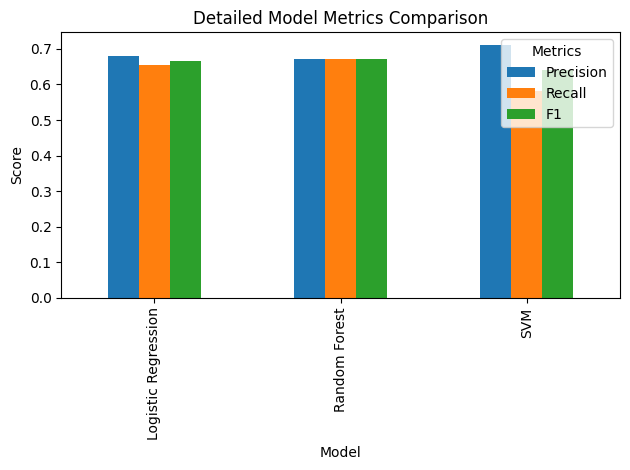

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_detailed_metrics(y_true, y_pred):
    return {
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred)
    }

detailed_metrics = {
    'Logistic Regression': get_detailed_metrics(y_test, log_pred),
    'Random Forest': get_detailed_metrics(y_test, rf_pred),
    'SVM': get_detailed_metrics(y_test, svm_pred)
}

print("\nDetailed Model Comparison:")
print("="*50)
for model_name, metrics in detailed_metrics.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.3f}")

metrics_df = pd.DataFrame(detailed_metrics).T
plt.figure(figsize=(10, 6))
metrics_df.plot(kind='bar')
plt.title('Detailed Model Metrics Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

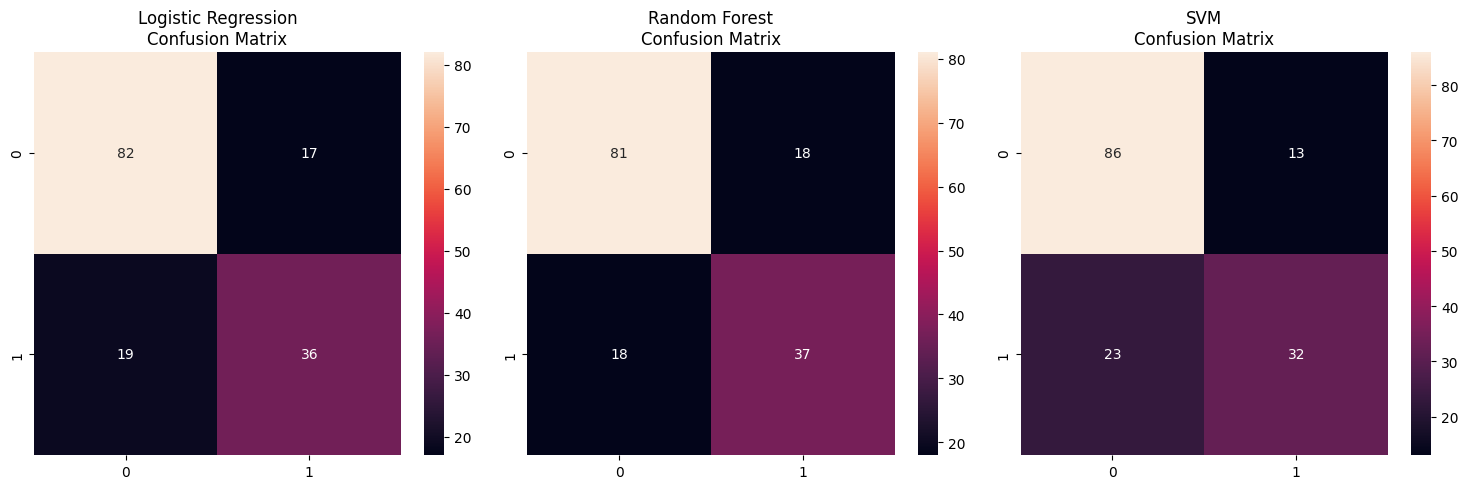

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.heatmap(confusion_matrix(y_test, log_pred), annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix')

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', ax=axes[1])
axes[1].set_title('Random Forest\nConfusion Matrix')

sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', ax=axes[2])
axes[2].set_title('SVM\nConfusion Matrix')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

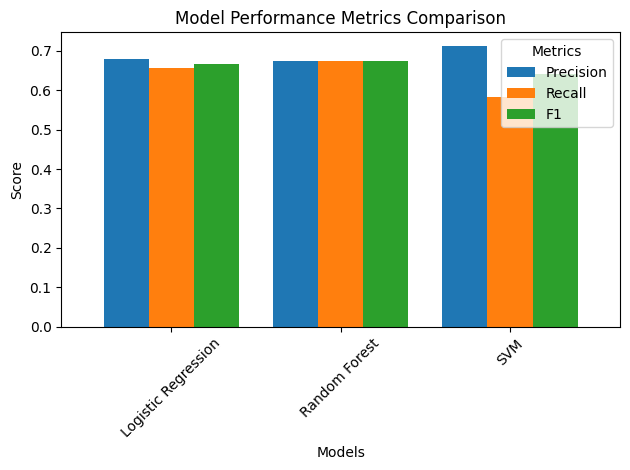


Model Recommendations:
1. For balanced performance: Random Forest
   - Consistent across all metrics (67.3%)
   - Best choice for general use

2. For high precision: SVM
   - Best at avoiding false positives (71.1%)
   - Good for cases where false positives are costly

3. For compromise: Logistic Regression
   - Good balance of metrics
   - Simple and interpretable


In [18]:
metrics_comparison = pd.DataFrame({
    'Precision': [0.679, 0.673, 0.711],
    'Recall': [0.655, 0.673, 0.582],
    'F1': [0.667, 0.673, 0.640]
}, index=['Logistic Regression', 'Random Forest', 'SVM'])

plt.figure(figsize=(12, 6))
metrics_comparison.plot(kind='bar', width=0.8)
plt.title('Model Performance Metrics Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.legend(title='Metrics')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nModel Recommendations:")
print("="*50)
print("1. For balanced performance: Random Forest")
print("   - Consistent across all metrics (67.3%)")
print("   - Best choice for general use")
print("\n2. For high precision: SVM")
print("   - Best at avoiding false positives (71.1%)")
print("   - Good for cases where false positives are costly")
print("\n3. For compromise: Logistic Regression")
print("   - Good balance of metrics")
print("   - Simple and interpretable")